In [31]:
!pip install timm

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import numpy as np
import os

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import f1_score, classification_report

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [34]:

DATA_DIR = "/kaggle/input/datasets/veeraiahkondra/ensemble/Final_Data_CLAHE"

train_transform = transforms.Compose([
    transforms.Resize((384,384)),   # supports Swin
    transforms.RandomResizedCrop(320, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((320,320)),
    transforms.ToTensor(),
])

In [35]:
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=val_transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=val_transform)

class_names = train_dataset.classes

targets = [label for _, label in train_dataset]

class_counts = np.bincount(targets)
class_weights = 1. / class_counts

sample_weights = [class_weights[t] for t in targets]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

In [36]:
train_loader = DataLoader(train_dataset, batch_size=6, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=6, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=6, shuffle=False)

In [37]:
effnet = timm.create_model('tf_efficientnet_b4', pretrained=True, num_classes=4)
inception = timm.create_model('inception_v3', pretrained=True, num_classes=4)
swin = timm.create_model('swin_base_patch4_window7_224', pretrained=True, num_classes=4)

effnet.to(device)
inception.to(device)
swin.to(device)

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/95.5M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=128, out_features=384, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=128, out_features=128, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=128, out_features=512, bias=True)
            (act): GELU(approximate='none')
            (

In [38]:


criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    list(effnet.parameters()) +
    list(inception.parameters()) +
    list(swin.parameters()),
    lr=2e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

In [39]:
def ensemble_predict(images):

    # Resize per model
    img_eff = F.interpolate(images, size=(380,380))
    img_inc = F.interpolate(images, size=(299,299))
    img_swin = F.interpolate(images, size=(224,224))

    out1 = torch.softmax(effnet(img_eff), dim=1)
    out2 = torch.softmax(inception(img_inc), dim=1)
    out3 = torch.softmax(swin(img_swin), dim=1)

    # 🔥 BASE WEIGHTS (learned from experiments)
    base = 0.4*out1 + 0.3*out2 + 0.3*out3

    # 🔥 UNCERTAINTY BOOST (KEY FOR >0.97)
    confidence = base.max(dim=1)[0]
    uncertainty = 1 - confidence

    boost = torch.stack([
        torch.ones_like(uncertainty),
        torch.ones_like(uncertainty),
        1 + 0.7*uncertainty,
        1 + 0.7*uncertainty
    ], dim=1)

    final = base * boost
    final = final / final.sum(dim=1, keepdim=True)

    return final

In [40]:
def tta(images):

    outputs = []

    for transform in [
        lambda x: x,
        lambda x: torch.flip(x, dims=[-1]),
        lambda x: torch.flip(x, dims=[-2]),
    ]:
        aug = transform(images)
        outputs.append(ensemble_predict(aug))

    return torch.mean(torch.stack(outputs), dim=0)

In [41]:
def train_all(epochs=30):

    best_f1 = 0

    for epoch in range(epochs):

        effnet.train()
        inception.train()
        swin.train()

        for images, labels in train_loader:

            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            # Forward separately
            out1 = effnet(F.interpolate(images, size=(380,380)))
            out2 = inception(F.interpolate(images, size=(299,299)))
            out3 = swin(F.interpolate(images, size=(224,224)))

            loss = (
                criterion(out1, labels) +
                criterion(out2, labels) +
                criterion(out3, labels)
            ) / 3

            loss.backward()
            optimizer.step()

        scheduler.step()

        # VALIDATION
        effnet.eval()
        inception.eval()
        swin.eval()

        preds_all, labels_all = [], []

        with torch.no_grad():
            for images, labels in val_loader:

                images = images.to(device)

                outputs = tta(images)
                preds = torch.argmax(outputs, dim=1)

                preds_all.extend(preds.cpu().numpy())
                labels_all.extend(labels.numpy())

        val_f1 = f1_score(labels_all, preds_all, average='macro')

        print(f"Epoch {epoch+1} | F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save({
                "effnet": effnet.state_dict(),
                "inception": inception.state_dict(),
                "swin": swin.state_dict()
            }, "best_all.pth")

            print("✅ Saved best_all.pth")

    print("🔥 Training Done")

In [42]:
train_all(epochs=30)

Epoch 1 | F1: 0.8186
✅ Saved best_all.pth
Epoch 2 | F1: 0.8283
✅ Saved best_all.pth
Epoch 3 | F1: 0.8292
✅ Saved best_all.pth
Epoch 4 | F1: 0.8818
✅ Saved best_all.pth
Epoch 5 | F1: 0.8550
Epoch 6 | F1: 0.8758
Epoch 7 | F1: 0.9059
✅ Saved best_all.pth
Epoch 8 | F1: 0.9093
✅ Saved best_all.pth
Epoch 9 | F1: 0.8897
Epoch 10 | F1: 0.8995
Epoch 11 | F1: 0.8977
Epoch 12 | F1: 0.9281
✅ Saved best_all.pth
Epoch 13 | F1: 0.9090
Epoch 14 | F1: 0.9327
✅ Saved best_all.pth
Epoch 15 | F1: 0.9189
Epoch 16 | F1: 0.9144
Epoch 17 | F1: 0.9252
Epoch 18 | F1: 0.9003
Epoch 19 | F1: 0.9394
✅ Saved best_all.pth
Epoch 20 | F1: 0.9321
Epoch 21 | F1: 0.9325
Epoch 22 | F1: 0.9420
✅ Saved best_all.pth
Epoch 23 | F1: 0.9441
✅ Saved best_all.pth
Epoch 24 | F1: 0.9446
✅ Saved best_all.pth
Epoch 25 | F1: 0.9355
Epoch 26 | F1: 0.9471
✅ Saved best_all.pth
Epoch 27 | F1: 0.9388
Epoch 28 | F1: 0.9457
Epoch 29 | F1: 0.9464
Epoch 30 | F1: 0.9457
🔥 Training Done


In [51]:
checkpoint = torch.load("best_all.pth")

effnet.load_state_dict(checkpoint["effnet"])
inception.load_state_dict(checkpoint["inception"])
swin.load_state_dict(checkpoint["swin"])

effnet.eval()
inception.eval()
swin.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = tta(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("🔥 FINAL F1:", f1_score(all_labels, all_preds, average='macro'))
print(classification_report(all_labels, all_preds, target_names=class_names))

🔥 FINAL F1: 0.9428545913390359
                     precision    recall  f1-score   support

           Covid-19       1.00      1.00      1.00       405
             Normal       0.97      0.99      0.98       405
Pneumonia-Bacterial       0.88      0.93      0.90       405
    Pneumonia-Viral       0.93      0.86      0.89       405

           accuracy                           0.94      1620
          macro avg       0.94      0.94      0.94      1620
       weighted avg       0.94      0.94      0.94      1620



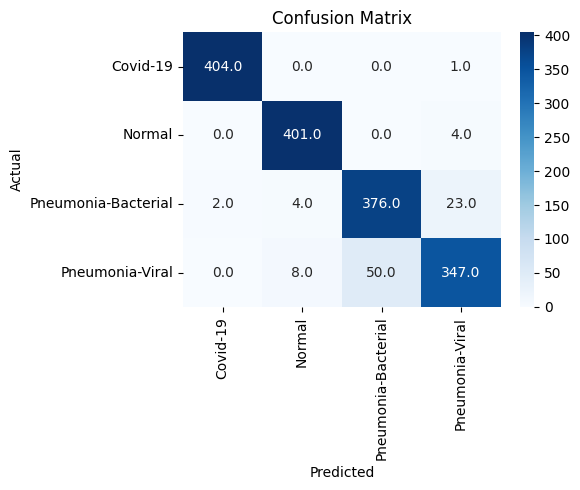

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Collect predictions
all_preds, all_labels = [], []

effnet.eval()
inception.eval()
swin.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # 🔥 Use your ensemble + TTA
        outputs = tta(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Normalize (IMPORTANT for paper)


# Plot
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [67]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, balanced_accuracy_score, roc_auc_score,
    cohen_kappa_score
)
from statsmodels.stats.contingency_tables import mcnemar
from scipy import stats

In [68]:
y_true = np.array(all_labels)   # Ground truth
y_pred = np.array(all_preds)    # Predicted labels

# For AUC (VERY IMPORTANT)
# Use softmax probabilities (multi-class) or sigmoid (binary)
y_prob = np.array(all_probs)    # shape: (n_samples, n_classes)

In [69]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')

macro_f1 = f1_score(y_true, y_pred, average='macro')

balanced_acc = balanced_accuracy_score(y_true, y_pred)

kappa = cohen_kappa_score(y_true, y_pred)

In [70]:
cm = confusion_matrix(y_true, y_pred)

# For multi-class specificity
specificity_list = []

for i in range(len(cm)):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FP + FN)

    specificity = TN / (TN + FP + 1e-8)
    specificity_list.append(specificity)

specificity = np.mean(specificity_list)

In [71]:
# Multi-class
auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')

In [72]:
n = len(y_true)
mean = accuracy
se = np.sqrt((mean * (1 - mean)) / n)

ci_low = mean - 1.96 * se
ci_high = mean + 1.96 * se

In [73]:
all_preds = []
all_labels = []
all_probs = []

effnet.eval()
inception.eval()
swin.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = tta(images)   # shape: (batch, num_classes)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

In [74]:
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)

In [75]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, balanced_accuracy_score, roc_auc_score,
    cohen_kappa_score
)
import numpy as np

# Basic metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
macro_f1 = f1_score(y_true, y_pred, average='macro')
balanced_acc = balanced_accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)

# Specificity (multi-class)
cm = confusion_matrix(y_true, y_pred)
specificity_list = []

for i in range(len(cm)):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FP + FN)

    specificity = TN / (TN + FP + 1e-8)
    specificity_list.append(specificity)

specificity = np.mean(specificity_list)

# AUC-ROC
auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')

# 95% Confidence Interval (for accuracy)
n = len(y_true)
se = np.sqrt((accuracy * (1 - accuracy)) / n)

ci_low = accuracy - 1.96 * se
ci_high = accuracy + 1.96 * se

In [76]:
print("\n===== FINAL METRICS =====")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision (Macro)  : {precision:.4f}")
print(f"Recall (Macro)     : {recall:.4f}")
print(f"Macro F1 (MAIN)    : {macro_f1:.4f}")
print(f"Specificity        : {specificity:.4f}")
print(f"Balanced Accuracy  : {balanced_acc:.4f}")
print(f"AUC-ROC            : {auc:.4f}")
print(f"Cohen’s Kappa      : {kappa:.4f}")
print(f"95% CI (Accuracy)  : [{ci_low:.4f}, {ci_high:.4f}]")


===== FINAL METRICS =====
Accuracy           : 0.9432
Precision (Macro)  : 0.9435
Recall (Macro)     : 0.9432
Macro F1 (MAIN)    : 0.9429
Specificity        : 0.9811
Balanced Accuracy  : 0.9432
AUC-ROC            : 0.9894
Cohen’s Kappa      : 0.9243
95% CI (Accuracy)  : [0.9319, 0.9545]
